Lab 22.2 – k-Fold Cross-Validation
Goal: Apply 5‑fold CV on a dataset, compare models and metrics, and understand variability across folds.

You’ll:

Use Breast Cancer (binary) dataset

Run 5‑fold Stratified CV with multiple metrics

Compare Logistic Regression vs Random Forest

Inspect per‑fold scores, mean ± std, and fit time

Build a quick model comparison table and visualize distributions

In [1]:
# pip install scikit-learn matplotlib seaborn numpy pandas
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             RocCurveDisplay, PrecisionRecallDisplay)
sns.set_theme(style='whitegrid', context='notebook')
np.random.seed(0)

1) Data

In [2]:
data = load_breast_cancer()
X, y = data.data, (data.target==0).astype(int)  # 1 = malignant (positive)
X.shape, np.bincount(y)

((569, 30), array([357, 212]))

2) Define models & CV

In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "LogReg": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
    "RandForest": RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1)
}

scoring = {"acc": "accuracy", "f1": "f1", "roc": "roc_auc"}

3) Run cross_validate and summarize

In [4]:
rows = []
per_fold = {}

for name, est in models.items():
    cvres = cross_validate(est, X, y, cv=cv, scoring=scoring,
                           return_train_score=True, return_estimator=False, n_jobs=-1)
    per_fold[name] = cvres
    rows.append({
        "model": name,
        "acc_mean":  np.mean(cvres["test_acc"]),  "acc_std":  np.std(cvres["test_acc"]),
        "f1_mean":   np.mean(cvres["test_f1"]),   "f1_std":   np.std(cvres["test_f1"]),
        "roc_mean":  np.mean(cvres["test_roc"]),  "roc_std":  np.std(cvres["test_roc"]),
        "fit_s_mean":np.mean(cvres["fit_time"])
    })

summary = pd.DataFrame(rows).round(3).sort_values("roc_mean", ascending=False)
summary

,model,acc_mean,acc_std,f1_mean,f1_std,roc_mean,roc_std,fit_s_mean
0,LogReg,0.974,0.017,0.963,0.024,0.995,0.005,0.011
1,RandForest,0.953,0.013,0.935,0.019,0.990,0.008,1.570


4) Visualize per‑fold score distributions

C:\Users\PRASAD\AppData\Local\Temp\ipykernel_8516\1315701124.py:14: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\Users\PRASAD\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


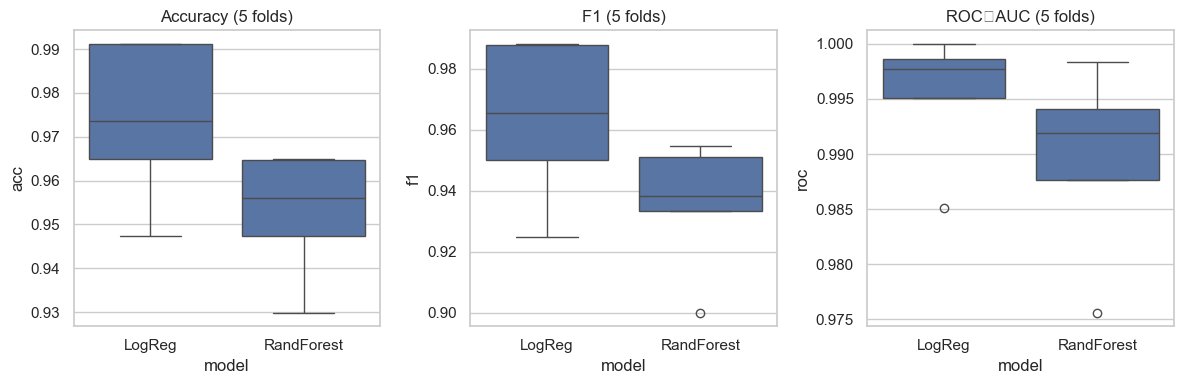

In [5]:
plot_df = []
for name, res in per_fold.items():
    for i, (a, f1, r) in enumerate(zip(res["test_acc"], res["test_f1"], res["test_roc"])):
        plot_df += [(name, i, a, f1, r)]
plot_df = pd.DataFrame(plot_df, columns=["model","fold","acc","f1","roc"])

fig, axes = plt.subplots(1,3, figsize=(12,4))
sns.boxplot(data=plot_df, x="model", y="acc", ax=axes[0])
axes[0].set_title("Accuracy (5 folds)")
sns.boxplot(data=plot_df, x="model", y="f1", ax=axes[1])
axes[1].set_title("F1 (5 folds)")
sns.boxplot(data=plot_df, x="model", y="roc", ax=axes[2])
axes[2].set_title("ROC‑AUC (5 folds)")
plt.tight_layout(); plt.show()

5) Cross‑validated predictions (confusion matrix & curves)

Use cross_val_predict to generate out‑of‑fold predictions for the entire dataset (each point predicted by a model that didn’t see it).

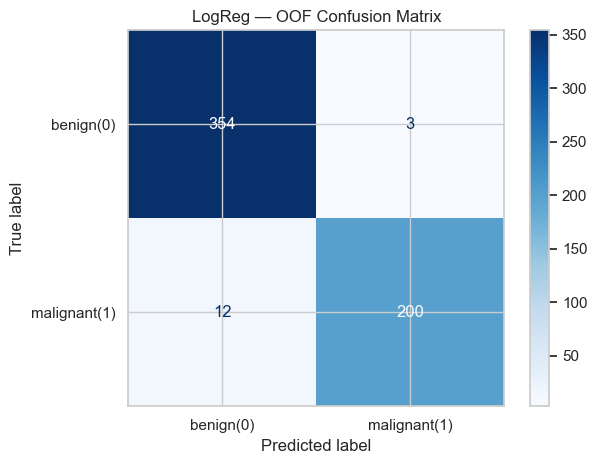

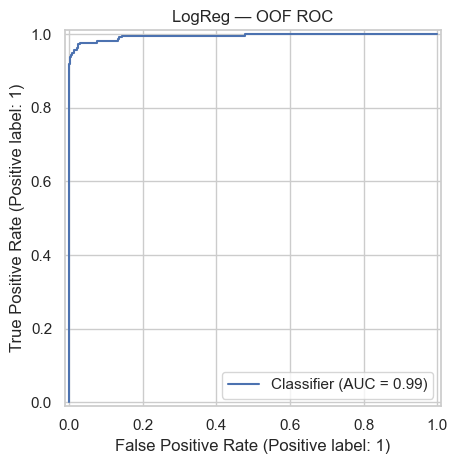

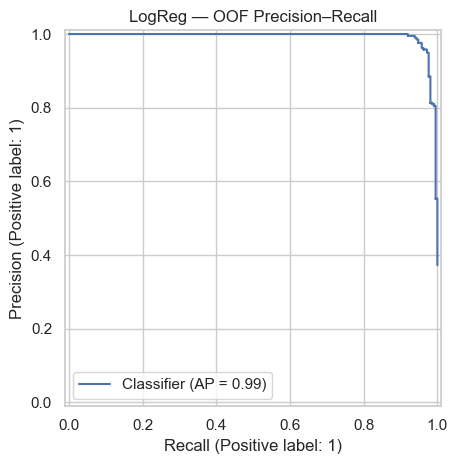

In [6]:
# Choose the better model by ROC‑AUC (from summary)
best_name = summary.iloc[0]["model"]
best_est  = models[best_name]

# Get OOF labels and probabilities
y_pred_oof = cross_val_predict(best_est, X, y, cv=cv, method="predict", n_jobs=-1)
y_proba_oof = cross_val_predict(best_est, X, y, cv=cv, method="predict_proba", n_jobs=-1)[:,1]

# Confusion matrix (OOF)
ConfusionMatrixDisplay(confusion_matrix(y, y_pred_oof),
                       display_labels=['benign(0)','malignant(1)']).plot(cmap='Blues')
plt.title(f'{best_name} — OOF Confusion Matrix'); plt.tight_layout(); plt.show()

# ROC & PR (OOF)
RocCurveDisplay.from_predictions(y, y_proba_oof)
plt.title(f'{best_name} — OOF ROC'); plt.tight_layout(); plt.show()

PrecisionRecallDisplay.from_predictions(y, y_proba_oof)
plt.title(f'{best_name} — OOF Precision–Recall'); plt.tight_layout(); plt.show()

Use StratifiedKFold for classification (preserve class balance).

In [7]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification

# 1. Generate synthetic data (imbalanced for demonstration)
# weights=[0.9, 0.1] creates a dataset where 90% is class 0 and 10% is class 1
X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, 
                           weights=[0.9, 0.1], random_state=42)

# 2. Initialize StratifiedKFold
# n_splits=5: 5-fold cross-validation
# shuffle=True: Shuffle data before splitting (highly recommended)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Example A: Manual Iteration
# Use this if you need granular control over the training loop
print("--- Manual Iteration ---")
model = LogisticRegression()
accuracies = []

for i, (train_index, test_index) in enumerate(skf.split(X, y)):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Fit the model
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    accuracies.append(score)
    
    # Verify class balance in the test set
    unique, counts = np.unique(y_test, return_counts=True)
    balance = dict(zip(unique, counts))
    print(f"Fold {i}: Accuracy={score:.4f}, Class Balance in Test Set={balance}")

print(f"Average Accuracy: {np.mean(accuracies):.4f}")

# 4. Example B: Using with cross_val_score
# This is the concise, standard way to run cross-validation
print("\n--- Using cross_val_score ---")
cv_scores = cross_val_score(model, X, y, cv=skf, scoring='accuracy')

print(f"Cross-validation scores: {cv_scores}")
print(f"Mean score: {cv_scores.mean():.4f}")


--- Manual Iteration ---
Fold 0: Accuracy=0.9050, Class Balance in Test Set={np.int64(0): np.int64(180), np.int64(1): np.int64(20)}
Fold 1: Accuracy=0.9250, Class Balance in Test Set={np.int64(0): np.int64(180), np.int64(1): np.int64(20)}
Fold 2: Accuracy=0.9300, Class Balance in Test Set={np.int64(0): np.int64(179), np.int64(1): np.int64(21)}
Fold 3: Accuracy=0.9350, Class Balance in Test Set={np.int64(0): np.int64(179), np.int64(1): np.int64(21)}
Fold 4: Accuracy=0.9250, Class Balance in Test Set={np.int64(0): np.int64(179), np.int64(1): np.int64(21)}
Average Accuracy: 0.9240

--- Using cross_val_score ---
Cross-validation scores: [0.905 0.925 0.93  0.935 0.925]
Mean score: 0.9240


Report mean ± std across folds; std estimates variability.

In [8]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification

# 1. Generate synthetic data
X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, 
                           weights=[0.9, 0.1], random_state=42)

# 2. Initialize StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Initialize Model
model = LogisticRegression()

# 4. Run Cross-Validation
# This returns an array of scores (one for each fold)
scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')

# 5. Report Mean ± Std
# We use 2 standard deviations (approx 95% confidence interval) or just 1 std.
# Here we report 1 standard deviation.
print(f"Individual Fold Scores: {scores}")
print(f"Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

# Optional: Check if variance is too high
if scores.std() > 0.05:
    print("Warning: High variance across folds. The model might be unstable.")
else:
    print("Model performance is relatively stable across folds.")


Individual Fold Scores: [0.905 0.925 0.93  0.935 0.925]
Accuracy: 0.9240 ± 0.0102
Model performance is relatively stable across folds.


Avoid using CV to both tune and report on the same folds—prefer nested CV or a hold‑out test for an unbiased final estimate.

Approach 1: Hold-out Test Set (Train/Test Split)
In this approach, you set aside a "clean" test set immediately. You perform cross-validation (with StratifiedKFold) only on the training set to tune parameters. The final score is reported on the hold-out set.

In [9]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.svm import SVC

# 1. Generate Data
X, y = make_classification(n_samples=1000, n_features=20, weights=[0.9, 0.1], random_state=42)

# 2. Create a Hold-out Test Set
# Crucial: Use stratify=y to maintain class balance in the split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 3. Configure Inner Cross-Validation for Tuning
# This CV is used ONLY to select the best hyperparameters
cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4. Define Hyperparameter Grid
param_grid = {'C': [0.1, 1, 10], 'kernel': ['rbf', 'linear']}

# 5. Run Grid Search
# GridSearchCV automatically uses the cv_inner strategy
search = GridSearchCV(SVC(), param_grid, cv=cv_inner, scoring='accuracy', n_jobs=-1)
search.fit(X_train, y_train)

# 6. Final Unbiased Evaluation
# We report performance on X_test, which the model has never seen during training or tuning
final_score = search.score(X_test, y_test)

print(f"Best Params found on Train Set: {search.best_params_}")
print(f"Best CV Score (biased estimate): {search.best_score_:.4f}")
print(f"Hold-out Test Score (unbiased estimate): {final_score:.4f}")


Best Params found on Train Set: {'C': 0.1, 'kernel': 'linear'}
Best CV Score (biased estimate): 0.9300
Hold-out Test Score (unbiased estimate): 0.9250


Approach 2: Nested Cross-Validation
If your dataset is small, a single train/test split might be unstable. Nested CV uses an inner loop to tune parameters and an outer loop to estimate error. This provides a mean ± std estimate of the model's performance process, rather than a specific model instance.

In [10]:
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.svm import SVC

# 1. Define Inner and Outer Cross-Validation strategies
# Inner: Used by GridSearchCV to find best params for a specific fold
cv_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=1)

# Outer: Used to evaluate the generalization error of the tuning process
cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=2)

# 2. Define the Model with Grid Search
# Note: We do not call .fit() here yet. We are defining the "process".
model_to_tune = GridSearchCV(
    SVC(), 
    param_grid={'C': [0.1, 1, 10], 'kernel': ['rbf', 'linear']}, 
    cv=cv_inner, 
    scoring='accuracy',
    n_jobs=-1
)

# 3. Run Nested Cross-Validation
# cross_val_score runs the outer loop. For every outer fold:
#   a. It splits data into outer_train and outer_test.
#   b. It calls model_to_tune.fit(outer_train).
#      -> This triggers the INNER loop (GridSearch) on outer_train.
#   c. It evaluates the best inner model on outer_test.
nested_scores = cross_val_score(model_to_tune, X, y, cv=cv_outer, scoring='accuracy')

# 4. Report Unbiased Performance
print(f"Nested CV Scores: {nested_scores}")
print(f"Unbiased Accuracy: {nested_scores.mean():.4f} ± {nested_scores.std():.4f}")


Nested CV Scores: [0.93  0.945 0.91  0.925 0.935]
Unbiased Accuracy: 0.9290 ± 0.0116


For pipelines with preprocessing (scaling, encoding), wrap it inside the CV to prevent leakage

1. Basic Pipeline (Scaling + Classification)
Here is how to wrap a scaler and a classifier into a single object. When you pass this pipeline to cross_val_score, it ensures fit is called on the training fold and transform is applied to the test fold using the training fold's statistics.

In [11]:
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# 1. Generate synthetic data
X, y = make_classification(n_samples=1000, n_features=20, random_state=42)

# 2. Define the Pipeline
# The pipeline sequentially applies a list of transforms and a final estimator.
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Step 1: Scale data
    ('svc', SVC(kernel='rbf'))     # Step 2: Classifier
])

# 3. Define the Splitter
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4. Run Cross-Validation
# The pipeline handles the logic:
# - For each fold, it fits StandardScaler ONLY on the training indices.
# - It then transforms the validation indices using the mean/std from training.
scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')

print(f"Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")


Accuracy: 0.8570 ± 0.0169


2. Advanced Pipeline (Mixed Types: Scaling + Encoding)
In real-world scenarios, you often have mixed data types (numerical and categorical). You should use ColumnTransformer inside your pipeline to apply different preprocessing to different columns without leakage.

In [12]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

# 1. Create a dummy dataframe with mixed types
df = pd.DataFrame({
    'age': np.random.randint(20, 60, 100),
    'salary': np.random.randn(100) * 10000 + 50000,
    'city': np.random.choice(['New York', 'London', 'Paris'], 100),
    'membership': np.random.choice(['Gold', 'Silver', 'Bronze'], 100),
    'target': np.random.randint(0, 2, 100)
})

X = df.drop('target', axis=1)
y = df['target']

# 2. Define column groups
numeric_features = ['age', 'salary']
categorical_features = ['city', 'membership']

# 3. Create Preprocessing Pipelines for each type
# Numeric: Impute missing values -> Scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical: Impute missing -> OneHotEncode
# handle_unknown='ignore' is crucial in CV to handle categories 
# that might appear in the test fold but not the training fold.
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# 4. Combine them with ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 5. Create the Final Pipeline
clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

# 6. Run Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(clf, X, y, cv=cv, scoring='accuracy')

print(f"Mean Accuracy with robust preprocessing: {scores.mean():.4f}")


Mean Accuracy with robust preprocessing: 0.5400


Add SVM (RBF) (SVC with scaling and probability=True) to models. Compare its ROC‑AUC mean ± std with LogReg and RF.

In [13]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 1. Generate synthetic dataset
# n_informative=10 makes the task non-trivial
X, y = make_classification(n_samples=1000, n_features=20, n_informative=10, 
                           weights=[0.8, 0.2], random_state=42)

# 2. Define Cross-Validation Strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Define Models
# Note: SVM and LogReg require scaling for optimal performance.
# Random Forest does not require scaling.
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(solver='liblinear', random_state=42))
    ]),
    
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    
    'SVM (RBF)': Pipeline([
        ('scaler', StandardScaler()),
        # probability=True is required for ROC-AUC scoring
        ('clf', SVC(kernel='rbf', probability=True, random_state=42)) 
    ])
}

# 4. Evaluate and Compare
results = []

print(f"{'Model':<25} | {'ROC-AUC (Mean ± Std)':<25}")
print("-" * 55)

for name, model in models.items():
    # scoring='roc_auc' requires the model to implement predict_proba
    scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    
    mean_score = scores.mean()
    std_score = scores.std()
    
    results.append({
        'Model': name, 
        'Mean': mean_score, 
        'Std': std_score
    })
    
    print(f"{name:<25} | {mean_score:.4f} ± {std_score:.4f}")

# Optional: Identify the most stable model (lowest std)
best_stability = min(results, key=lambda x: x['Std'])
best_performance = max(results, key=lambda x: x['Mean'])

print("-" * 55)
print(f"Best Performance: {best_performance['Model']} ({best_performance['Mean']:.4f})")
print(f"Most Stable:      {best_stability['Model']} (Std: {best_stability['Std']:.4f})")


Model                     | ROC-AUC (Mean ± Std)     
-------------------------------------------------------
Logistic Regression       | 0.9011 ± 0.0197
Random Forest             | 0.9682 ± 0.0131
SVM (RBF)                 | 0.9785 ± 0.0131
-------------------------------------------------------
Best Performance: SVM (RBF) (0.9785)
Most Stable:      SVM (RBF) (Std: 0.0131)


Key Implementation Details
probability=True: The SVC implementation in scikit-learn does not calculate probabilities by default (it uses a decision boundary). Setting this to True enables Platt scaling (an internal 5-fold cross-validation) to generate probabilities required for the ROC-AUC calculation.
Scaling:
SVM: Crucial. The RBF kernel relies on Euclidean distance; without scaling, features with larger ranges would dominate the distance calculation.
Logistic Regression: Highly recommended. It ensures the regularization penalty (L1/L2) applies equally to all features.
Random Forest: Not applied. Tree splits are based on ordering, not magnitude/distance.
n_jobs=-1: This argument in cross_val_score allows the folds to be processed in parallel, which significantly speeds up the SVM training (as probability=True is computationally expensive).
Generated by 

Switch to RepeatedStratifiedKFold (e.g., 5 folds × 3 repeats). Does the std shrink? How does mean ROC‑AUC change?

In [14]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 1. Generate Data
X, y = make_classification(n_samples=1000, n_features=20, n_informative=10, 
                           weights=[0.8, 0.2], random_state=42)

# 2. Define Models
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(solver='liblinear', random_state=42))
    ]),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', probability=True, random_state=42))
    ])
}

# 3. Define CV Strategies
cv_standard = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_repeated = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)

# 4. Run Comparison
results = []

print(f"{'Model':<20} | {'CV Strategy':<15} | {'Mean ROC-AUC':<12} | {'Std':<8} | {'Std Err (SEM)':<10}")
print("-" * 85)

for name, model in models.items():
    # --- Standard 5-Fold ---
    scores_std = cross_val_score(model, X, y, cv=cv_standard, scoring='roc_auc', n_jobs=-1)
    sem_std = scores_std.std() / np.sqrt(len(scores_std)) # Standard Error
    
    print(f"{name:<20} | {'5-Fold':<15} | {scores_std.mean():.4f}       | {scores_std.std():.4f}   | {sem_std:.4f}")
    
    # --- Repeated 5x3 Fold ---
    scores_rep = cross_val_score(model, X, y, cv=cv_repeated, scoring='roc_auc', n_jobs=-1)
    sem_rep = scores_rep.std() / np.sqrt(len(scores_rep)) # Standard Error
    
    print(f"{name:<20} | {'5x3 Repeated':<15} | {scores_rep.mean():.4f}       | {scores_rep.std():.4f}   | {sem_rep:.4f}")
    print("-" * 85)


Model                | CV Strategy     | Mean ROC-AUC | Std      | Std Err (SEM)
-------------------------------------------------------------------------------------
Logistic Regression  | 5-Fold          | 0.9011       | 0.0197   | 0.0088
Logistic Regression  | 5x3 Repeated    | 0.9020       | 0.0143   | 0.0037
-------------------------------------------------------------------------------------
Random Forest        | 5-Fold          | 0.9682       | 0.0131   | 0.0059
Random Forest        | 5x3 Repeated    | 0.9711       | 0.0148   | 0.0038
-------------------------------------------------------------------------------------
SVM (RBF)            | 5-Fold          | 0.9785       | 0.0131   | 0.0058
SVM (RBF)            | 5x3 Repeated    | 0.9799       | 0.0107   | 0.0028
-------------------------------------------------------------------------------------
